# Random Search Hyperparameter Tuning – FER-2013 ResNet34 + Mixup

This notebook performs an **optimized random search** with the following improvements:

## 🚀 Key Features:
1. **ResNet34** (stronger than ResNet18)
2. **Mixup augmentation** for better generalization
3. **Reduced search space** (27 combos: 3 LR × 3 aug × 3 opt, fixed batch size & scheduler)
4. **Aggressive early stopping** (patience=1) and shorter epochs (2+5)
5. **Resume-safe**: Auto-skips already-trained combinations
6. **Global best tracking**: Results summary shows best model from ALL saved models

## ⚡ Efficiency:
- Only trains new, untrained combinations
- Set `N_RANDOM` to control how many combos to train per run
- Can run in parallel with other notebooks
- No duplicate work across sessions

**Tip:** Run this notebook multiple times to explore the search space incrementally. Each run will skip already-trained combos and find the global best automatically.

In [1]:
!ls /kaggle/input/datasets/hritik567/fer-hypertuning-checkpoints/saved_models

resnet18_combo01_lr5e-5_bs32_aug_light_opt_adam_sched_step_acc0.6300.pth
resnet18_combo02_lr5e-5_bs32_aug_light_opt_adam_sched_cosine_acc0.6361.pth
resnet18_combo03_lr5e-5_bs32_aug_light_opt_adam_sched_plateau_acc0.6344.pth
resnet18_combo04_lr5e-5_bs32_aug_light_opt_adamw_sched_step_acc0.6364.pth
resnet18_combo05_lr5e-5_bs32_aug_light_opt_adamw_sched_cosine_acc0.6255.pth
resnet18_combo06_lr5e-5_bs32_aug_light_opt_adamw_sched_plateau_acc0.6241.pth
resnet18_combo07_lr5e-5_bs32_aug_light_opt_sgd_sched_step_acc0.4971.pth
resnet18_combo08_lr5e-5_bs32_aug_light_opt_sgd_sched_cosine_acc0.5024.pth
resnet18_combo09_lr5e-5_bs32_aug_light_opt_sgd_sched_plateau_acc0.5375.pth
resnet18_combo10_lr5e-5_bs32_aug_medium_opt_adam_sched_step_acc0.6353.pth
resnet18_combo11_lr5e-5_bs32_aug_medium_opt_adam_sched_cosine_acc0.6406.pth
resnet18_combo12_lr5e-5_bs32_aug_medium_opt_adam_sched_plateau_acc0.6381.pth
resnet18_combo13_lr5e-5_bs32_aug_medium_opt_adamw_sched_step_acc0.6386.pth
resnet18_combo14_lr5e-5_bs

In [2]:
# ====== KAGGLE/LOCAL SETUP ======
import os, sys, shutil
from pathlib import Path

# Check if running on Kaggle
is_kaggle = os.path.exists('/kaggle')
print(f"Running on Kaggle: {is_kaggle}")
print(f"Python version: {sys.version.split()[0]}")

if is_kaggle:
    DATASET_PATH = Path("/kaggle/input/facial-expression-recognition/FER_data.csv")
    SAVE_DIR = Path("/kaggle/working/saved_models")

    # ✅ Correct path to previously saved models
    PREV_MODELS_DIR = Path(
        "/kaggle/input/datasets/hritik567/fer-hypertuning-checkpoints/saved_models"
    )

else:
    PROJECT_ROOT = Path.cwd().parents[1]
    DATASET_PATH = PROJECT_ROOT / "Datasets" / "FER_data.csv"
    SAVE_DIR = PROJECT_ROOT / "Models" / "Saved_Models"
    PREV_MODELS_DIR = None

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- COPY PREVIOUS MODELS INTO WORKING ----------
if is_kaggle and PREV_MODELS_DIR.exists():
    print("Copying previous saved models into working directory...")
    copied = 0
    for file in PREV_MODELS_DIR.glob("*.pth"):
        dest = SAVE_DIR / file.name
        if not dest.exists():
            shutil.copy(file, dest)
            copied += 1
    print(f"✓ {copied} models copied into: {SAVE_DIR}")
else:
    print("No previous saved models found.")

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

print(f"✓ Dataset found: {DATASET_PATH}")
print(f"✓ Models will be saved to: {SAVE_DIR}")

Running on Kaggle: True
Python version: 3.12.12
Copying previous saved models into working directory...
✓ 28 models copied into: /kaggle/working/saved_models
✓ Dataset found: /kaggle/input/facial-expression-recognition/FER_data.csv
✓ Models will be saved to: /kaggle/working/saved_models


In [3]:
# Imports and device setup
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import pandas as pd
import numpy as np
from PIL import Image
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import itertools, random, copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# 1. Load & Inspect Dataset
data = pd.read_csv(DATASET_PATH)
data.columns = data.columns.str.strip()
print(f"Total samples : {len(data)}")
print(f"Columns       : {list(data.columns)}")
print(f"\nEmotion distribution:\n{data['emotion'].value_counts().sort_index()}")
FER_LABELS = {0: "angry", 1: "disgust", 2: "fear", 3: "happy", 4: "sad", 5: "surprise", 6: "neutral"}
class_names = [FER_LABELS[i] for i in range(7)]
NUM_CLASSES = 7

Total samples : 35887
Columns       : ['emotion', 'Usage', 'pixels']

Emotion distribution:
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64


In [5]:
# 2. Dataset Class & Augmentation Presets
class FERDataset(Dataset):
    def __init__(self, dataframe, split, transform=None):
        self.data = dataframe[dataframe["Usage"] == split].reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        label = int(row["emotion"])
        pixels = np.array(row["pixels"].split(), dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels)
        if self.transform:
            image = self.transform(image)
        return image, label

def build_transform(aug_level: str = "medium"):
    base = [transforms.Resize((224, 224)), transforms.Grayscale(num_output_channels=3)]
    if aug_level == "light":
        aug = [transforms.RandomHorizontalFlip(p=0.3), transforms.ColorJitter(brightness=0.1, contrast=0.1)]
    elif aug_level == "medium":
        aug = [transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(10), transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), transforms.ColorJitter(brightness=0.2, contrast=0.2)]
    elif aug_level == "heavy":
        aug = [transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15), transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))]
    else:
        raise ValueError(f"Unknown aug_level: {aug_level}")
    tail = [transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]
    if aug_level == "heavy":
        erasing = aug.pop(-1)
        return transforms.Compose(base + aug + tail + [erasing])
    return transforms.Compose(base + aug + tail)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print("Dataset class & augmentation presets ready.")

Dataset class & augmentation presets ready.


In [6]:
# 3. Compute Class Weights
train_labels = data[data["Usage"] == "Training"]["emotion"].values
counts = Counter(train_labels)
class_weights = torch.tensor([1.0 / counts[i] for i in range(NUM_CLASSES)], dtype=torch.float).to(device)
print("Class weights (inverse frequency):")
for i, w in enumerate(class_weights):
    print(f"  {FER_LABELS[i]:>10s}: {w:.6f}")

Class weights (inverse frequency):
       angry: 0.000250
     disgust: 0.002294
        fear: 0.000244
       happy: 0.000139
         sad: 0.000207
    surprise: 0.000315
     neutral: 0.000201


In [7]:
# 4. Reduced Hyperparameter Search Space (best-practice defaults)
HYPERPARAM_GRID = {
    "lr": [5e-5, 1e-4, 3e-4],
    "batch_size": [64],  # Fixed
    "aug_level": ["light", "medium", "heavy"],
    "optimizer": ["adam", "adamw", "sgd"],
    "scheduler": ["cosine"],  # Fixed
}
PHASE1_EPOCHS = 2  # Shorter runs for fast search
PHASE2_EPOCHS = 5
PATIENCE = 1  # Aggressive early stopping
all_combos = list(itertools.product(
    HYPERPARAM_GRID["lr"],
    HYPERPARAM_GRID["batch_size"],
    HYPERPARAM_GRID["aug_level"],
    HYPERPARAM_GRID["optimizer"],
    HYPERPARAM_GRID["scheduler"],
))
print(f"Total hyperparameter combinations: {len(all_combos)}")

Total hyperparameter combinations: 27


In [8]:
# 5. Training & Evaluation Helpers (same as grid)
def make_optimizer(name: str, params, lr: float):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    elif name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    elif name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=1e-4)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

def make_scheduler(name: str, optimizer, total_epochs: int):
    if name == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    elif name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)
    elif name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    else:
        raise ValueError(f"Unknown scheduler: {name}")

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return correct / total

@torch.no_grad()
def full_evaluation(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(labels.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    acc = accuracy_score(y_true, y_pred)
    return y_true, y_pred, acc

def build_model_name(combo_idx, lr, bs, aug, opt, sched, val_acc):
    lr_str = f"{lr:.0e}".replace("+", "").replace("-0", "-")
    acc_str = f"{val_acc:.4f}"
    name = (
        f"resnet18_combo{combo_idx:02d}"
        f"_lr{lr_str}"
        f"_bs{bs}"
        f"_aug_{aug}"
        f"_opt_{opt}"
        f"_sched_{sched}"
        f"_acc{acc_str}"
        ".pth"
    )
    return name
print("Helper functions defined.")

Helper functions defined.


In [9]:
# 6. Random Search Loop with Resume/Skip Logic (ResNet34 + Mixup)
import json
N_RANDOM = 10  # Fewer combos needed due to reduced space

def mixup_data(x, y, alpha=0.4):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Check for already-trained combos (only ResNet34 models with Mixup)
existing_model_files = sorted(list(SAVE_DIR.glob("resnet34_*.pth")))
trained_combos_set = set()
for model_file in existing_model_files:
    try:
        ckpt = torch.load(model_file, map_location='cpu')
        hp = ckpt.get('hyperparams', {})
        combo_tuple = (
            float(hp.get('lr', -1)),
            int(hp.get('batch_size', -1)),
            hp.get('aug_level', ''),
            hp.get('optimizer', ''),
            hp.get('scheduler', ''),
        )
        trained_combos_set.add(combo_tuple)
    except Exception as e:
        print(f"Warning: Could not read {model_file.name}: {e}")

untrained_combos = [c for c in all_combos if c not in trained_combos_set]
print(f"Already trained (ResNet34): {len(trained_combos_set)} | Untrained: {len(untrained_combos)}")

if len(untrained_combos) == 0:
    print("All combinations have already been trained!")
else:
    random.seed(42)
    combos_to_run = random.sample(untrained_combos, min(N_RANDOM, len(untrained_combos)))
    print(f"Randomly selected {len(combos_to_run)} new combos to train.")
    results_log = []
    val_dataset = FERDataset(data, split="PublicTest", transform=val_transform)
    for combo_idx, (lr, bs, aug, opt_name, sched_name) in enumerate(combos_to_run, start=1):
        tag = f"RandomCombo {combo_idx}/{len(combos_to_run)} | lr={lr} bs={bs} aug={aug} opt={opt_name} sched={sched_name}"
        print(f"\n{'='*70}")
        print(f"  {tag}")
        print(f"{'='*70}")
        train_transform = build_transform(aug)
        train_dataset = FERDataset(data, split="Training", transform=train_transform)
        train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=0, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False, num_workers=0, pin_memory=True)
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
        model = model.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        # Phase 1: Classifier head only
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
        optimizer = make_optimizer(opt_name, model.fc.parameters(), lr=lr * 10)
        scheduler = make_scheduler(sched_name, optimizer, PHASE1_EPOCHS)
        for epoch in range(1, PHASE1_EPOCHS + 1):
            model.train()
            total_loss, correct, total = 0.0, 0, 0
            pbar = tqdm(train_loader, desc="  Train", leave=False)
            for images, labels in pbar:
                images, labels = images.to(device), labels.to(device)
                mixed_x, y_a, y_b, lam = mixup_data(images, labels)
                optimizer.zero_grad()
                outputs = model(mixed_x)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += images.size(0)
                pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
            val_acc = evaluate(model, val_loader)
            print(f"    [P1 Epoch {epoch}/{PHASE1_EPOCHS}] Loss={total_loss/total:.4f}  ValAcc={val_acc:.4f}")
            if sched_name == "plateau":
                scheduler.step(val_acc)
            else:
                scheduler.step()
        # Phase 2: Fine-tune last 2 blocks + fc
        for name, param in model.named_parameters():
            if "layer3" in name or "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        trainable_params = filter(lambda p: p.requires_grad, model.parameters())
        optimizer = make_optimizer(opt_name, trainable_params, lr=lr)
        scheduler = make_scheduler(sched_name, optimizer, PHASE2_EPOCHS)
        best_val_acc = 0.0
        best_state = None
        patience_ctr = 0
        for epoch in range(1, PHASE2_EPOCHS + 1):
            model.train()
            total_loss, correct, total = 0.0, 0, 0
            pbar = tqdm(train_loader, desc="  Train", leave=False)
            for images, labels in pbar:
                images, labels = images.to(device), labels.to(device)
                mixed_x, y_a, y_b, lam = mixup_data(images, labels)
                optimizer.zero_grad()
                outputs = model(mixed_x)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += images.size(0)
                pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
            val_acc = evaluate(model, val_loader)
            print(f"    [P2 Epoch {epoch}/{PHASE2_EPOCHS}] Loss={total_loss/total:.4f}  ValAcc={val_acc:.4f}")
            if sched_name == "plateau":
                scheduler.step(val_acc)
            else:
                scheduler.step()
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = copy.deepcopy(model.state_dict())
                patience_ctr = 0
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE:
                    print(f"    Early stopping at epoch {epoch}.")
                    break
        if best_state is not None:
            model.load_state_dict(best_state)
        model_filename = f"resnet34_combo{combo_idx:02d}_lr{lr:.0e}_bs{bs}_aug_{aug}_opt_{opt_name}_sched_{sched_name}_acc{best_val_acc:.4f}.pth"
        save_path = SAVE_DIR / model_filename
        torch.save({
            "model_state_dict": model.state_dict(),
            "num_classes": NUM_CLASSES,
            "hyperparams": {
                "lr": lr,
                "batch_size": bs,
                "aug_level": aug,
                "optimizer": opt_name,
                "scheduler": sched_name,
                "mixup": True,
                "mixup_alpha": 0.4,
            },
            "best_val_acc": best_val_acc,
        }, save_path)
        print(f"  ✓ Saved → {save_path.name}  (ValAcc={best_val_acc:.4f})")
        results_log.append({
            "combo_idx": combo_idx,
            "lr": lr,
            "batch_size": bs,
            "aug_level": aug,
            "optimizer": opt_name,
            "scheduler": sched_name,
            "best_val_acc": best_val_acc,
            "model_file": model_filename,
        })
        del model, optimizer, scheduler, best_state
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    print(f"\n{'='*70}")
    print(f"✅ RANDOM SEARCH COMPLETE")
    print(f"{'='*70}")
    print(f"Total new combos processed: {len(results_log)}")


Already trained (ResNet34): 5 | Untrained: 22
Randomly selected 10 new combos to train.

  RandomCombo 1/10 | lr=0.0003 bs=64 aug=heavy opt=adamw sched=cosine
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 236MB/s]


    [P1 Epoch 1/2] Loss=1.8937  ValAcc=0.2653


    [P1 Epoch 2/2] Loss=1.8171  ValAcc=0.3692


    [P2 Epoch 1/5] Loss=1.5932  ValAcc=0.4762


...

    [P2 Epoch 1/5] Loss=1.5204  ValAcc=0.5511


    [P2 Epoch 2/5] Loss=1.3609  ValAcc=0.5862


    [P2 Epoch 3/5] Loss=1.2734  ValAcc=0.6222


    [P2 Epoch 4/5] Loss=1.1959  ValAcc=0.6486


    [P2 Epoch 5/5] Loss=1.1573  ValAcc=0.6595
  ✓ Saved → resnet34_combo10_lr1e-04_bs64_aug_medium_opt_adamw_sched_cosine_acc0.6595.pth  (ValAcc=0.6595)

✅ RANDOM SEARCH COMPLETE
Total new combos processed: 10


In [10]:
# 7. Results Summary & Best Model (from ALL saved models)
print("📊 Scanning all saved models to find the best one...\n")

# Scan ALL saved model files (both ResNet18 and ResNet34)
all_saved_models = sorted(list(SAVE_DIR.glob("resnet18_*.pth")) + list(SAVE_DIR.glob("resnet34_*.pth")))

if len(all_saved_models) == 0:
    print("⚠️ No saved models found. Train some models first.")
else:
    all_results = []
    for model_file in all_saved_models:
        try:
            ckpt = torch.load(model_file, map_location='cpu')
            hp = ckpt.get('hyperparams', {})
            acc = ckpt.get('best_val_acc', 0.0)
            
            # Extract model architecture from filename
            if model_file.name.startswith('resnet18_'):
                model_arch = 'ResNet18'
            elif model_file.name.startswith('resnet34_'):
                model_arch = 'ResNet34'
            else:
                model_arch = 'Unknown'
            
            all_results.append({
                "model": model_arch,
                "lr": hp.get('lr', -1),
                "batch_size": hp.get('batch_size', -1),
                "aug_level": hp.get('aug_level', 'unknown'),
                "optimizer": hp.get('optimizer', 'unknown'),
                "scheduler": hp.get('scheduler', 'unknown'),
                "best_val_acc": acc,
                "model_file": model_file.name,
            })
        except Exception as e:
            print(f"Warning: Could not read {model_file.name}: {e}")
    
    if len(all_results) == 0:
        print("⚠️ No valid model files found.")
    else:
        results_df = pd.DataFrame(all_results).sort_values("best_val_acc", ascending=False)
        results_df.to_csv(SAVE_DIR / "all_models_results.csv", index=False)
        
        print(f"✅ Found {len(all_results)} saved models\n")
        print("Top 10 models by validation accuracy:")
        print("="*90)
        print(results_df.head(10).to_string(index=False))
        print(f"\nFull results saved to: {SAVE_DIR / 'all_models_results.csv'}")
        
        # Show model distribution
        model_counts = results_df['model'].value_counts()
        print(f"\n📊 Model Distribution:")
        for model, count in model_counts.items():
            print(f"  {model}: {count} models")
        
        # Show best model details
        best_run = results_df.iloc[0]
        print(f"\n{'='*70}")
        print(f"  🏆 BEST MODEL ACROSS ALL RUNS")
        print(f"{'='*70}")
        print(f"  Architecture : {best_run['model']}")
        print(f"  ValAcc       : {best_run['best_val_acc']:.4f}")
        print(f"  LR           : {best_run['lr']}")
        print(f"  Batch Size   : {int(best_run['batch_size'])}")
        print(f"  Augmentation : {best_run['aug_level']}")
        print(f"  Optimizer    : {best_run['optimizer']}")
        print(f"  Scheduler    : {best_run['scheduler']}")
        print(f"  Model File   : {best_run['model_file']}")
        print(f"{'='*70}")

📊 Scanning all saved models to find the best one...

✅ Found 38 saved models

Top 10 models by validation accuracy:
   model      lr  batch_size aug_level optimizer scheduler  best_val_acc                                                                    model_file
ResNet34 0.00030          64    medium      adam    cosine      0.669546  resnet34_combo06_lr3e-04_bs64_aug_medium_opt_adam_sched_cosine_acc0.6695.pth
ResNet34 0.00010          64     light     adamw    cosine      0.667595  resnet34_combo05_lr1e-04_bs64_aug_light_opt_adamw_sched_cosine_acc0.6676.pth
ResNet34 0.00010          64    medium     adamw    cosine      0.659515 resnet34_combo10_lr1e-04_bs64_aug_medium_opt_adamw_sched_cosine_acc0.6595.pth
ResNet34 0.00030          64     heavy     adamw    cosine      0.650599  resnet34_combo01_lr3e-04_bs64_aug_heavy_opt_adamw_sched_cosine_acc0.6506.pth
ResNet34 0.00005          64     light     adamw    cosine      0.650042  resnet34_combo03_lr5e-05_bs64_aug_light_opt_adamw_sched

🚀 Evaluating ResNet34 model...

Best model validation accuracy: 0.6695


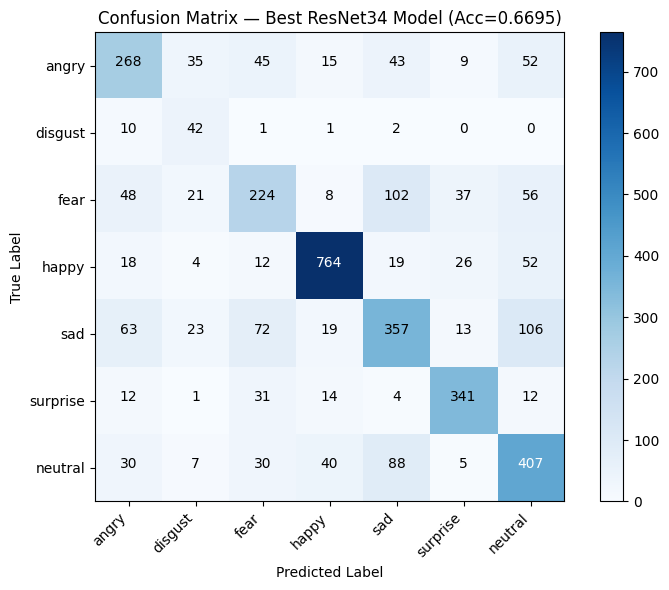


===== Per-class Precision / Recall / F1 =====

              precision    recall  f1-score   support

       angry     0.5969    0.5739    0.5852       467
     disgust     0.3158    0.7500    0.4444        56
        fear     0.5398    0.4516    0.4918       496
       happy     0.8873    0.8536    0.8702       895
         sad     0.5805    0.5467    0.5631       653
    surprise     0.7912    0.8217    0.8061       415
     neutral     0.5942    0.6705    0.6300       607

    accuracy                         0.6695      3589
   macro avg     0.6151    0.6669    0.6273      3589
weighted avg     0.6761    0.6695    0.6703      3589

===== Overall F1 Scores =====
Macro F1    : 0.6273
Weighted F1 : 0.6703
Micro F1    : 0.6695


In [11]:
# 8. Evaluate Best Model — Confusion Matrix & Metrics
if 'best_run' not in locals():
    print("⚠️ No best model found. Run the results summary cell above first.")
else:
    best_model_path = SAVE_DIR / best_run["model_file"]
    checkpoint = torch.load(best_model_path, map_location=device)
    
    # Load the correct model architecture
    model_arch = best_run['model']
    if model_arch == 'ResNet18':
        best_model = models.resnet18(weights=None)
    elif model_arch == 'ResNet34':
        best_model = models.resnet34(weights=None)
    else:
        raise ValueError(f"Unknown model architecture: {model_arch}")
    
    best_model.fc = nn.Linear(best_model.fc.in_features, checkpoint["num_classes"])
    best_model.load_state_dict(checkpoint["model_state_dict"])
    best_model = best_model.to(device)
    best_model.eval()
    
    print(f"🚀 Evaluating {model_arch} model...\n")
    
    val_loader_eval = DataLoader(FERDataset(data, split="PublicTest", transform=val_transform), batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
    y_true, y_pred, acc = full_evaluation(best_model, val_loader_eval)
    print(f"Best model validation accuracy: {acc:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix — Best {model_arch} Model (Acc={acc:.4f})")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()
    print("\n===== Per-class Precision / Recall / F1 =====\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    micro_f1 = f1_score(y_true, y_pred, average="micro")
    print("===== Overall F1 Scores =====")
    print(f"Macro F1    : {macro_f1:.4f}")
    print(f"Weighted F1 : {weighted_f1:.4f}")
    print(f"Micro F1    : {micro_f1:.4f}")

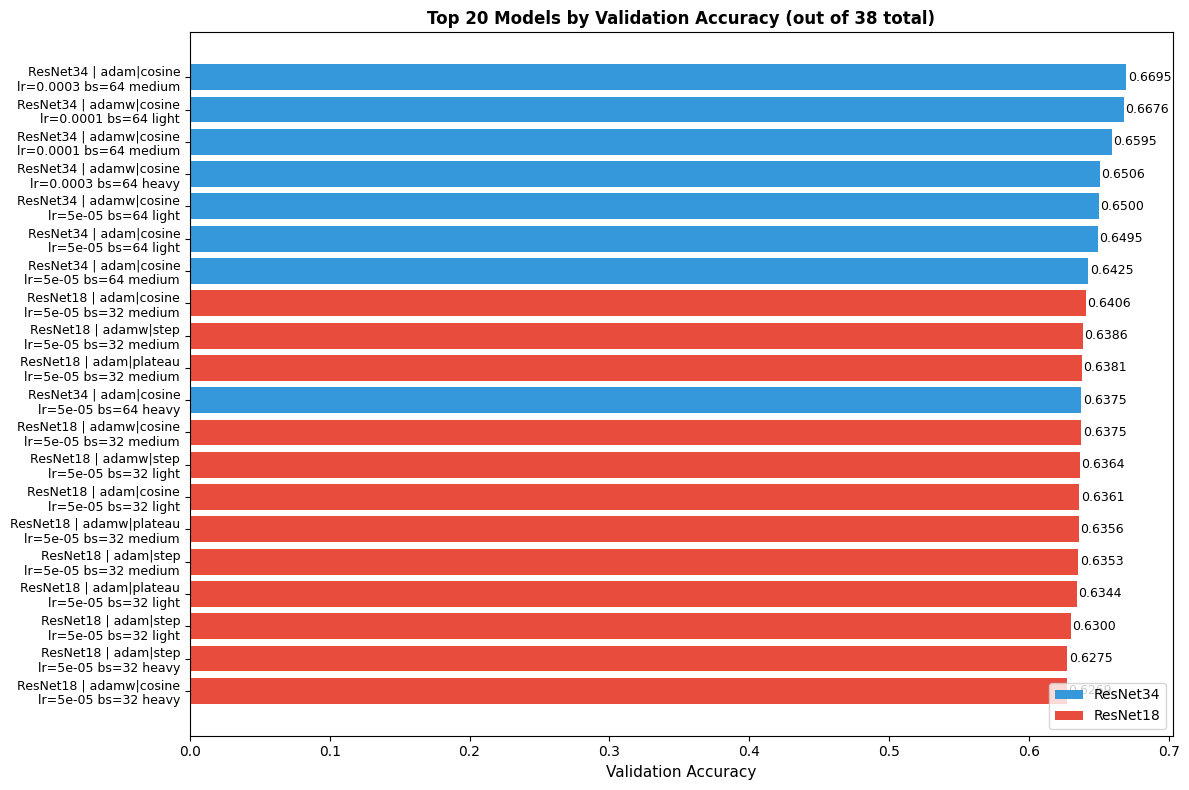


💾 Total models saved: 38
📁 Saved in: /kaggle/working/saved_models


In [12]:
# 9. Accuracy Comparison Bar Chart (All Saved Models)
if 'results_df' not in locals() or len(results_df) == 0:
    print("⚠️ No results to visualize. Run the results summary cell above first.")
else:
    # Show top 20 models for better visualization
    top_n = min(20, len(results_df))
    results_sorted = results_df.head(top_n).sort_values("best_val_acc", ascending=True)
    labels = [
        f"{r['model']} | {r['optimizer']}|{r['scheduler']}\nlr={r['lr']} bs={int(r['batch_size'])} {r['aug_level']}"
        for _, r in results_sorted.iterrows()
    ]
    fig, ax = plt.subplots(figsize=(12, max(6, len(labels) * 0.4)))
    
    # Color code by model architecture
    colors = ['#3498db' if r['model'] == 'ResNet34' else '#e74c3c' for _, r in results_sorted.iterrows()]
    bars = ax.barh(range(len(labels)), results_sorted["best_val_acc"], color=colors)
    
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Validation Accuracy", fontsize=11)
    ax.set_title(f"Top {top_n} Models by Validation Accuracy (out of {len(results_df)} total)", fontsize=12, fontweight='bold')
    for bar, val in zip(bars, results_sorted["best_val_acc"]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=9)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#3498db', label='ResNet34'),
                      Patch(facecolor='#e74c3c', label='ResNet18')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    print(f"\n💾 Total models saved: {len(results_df)}")
    print(f"📁 Saved in: {SAVE_DIR}")

## 10. Download Results (Kaggle)
After the notebook finishes:
1. All models are saved in `/kaggle/working/saved_models/`
2. Results CSV: `/kaggle/working/saved_models/randomsearch_results.csv`
3. Click **"Save Version"** at top right
4. Once complete, go to **"Output"** tab to download all files
5. Or use the cell below to create a ZIP file

In [13]:
# Optional: Create a ZIP file of all models for easy download
import shutil
from pathlib import Path
if Path("/kaggle").exists():
    zip_path = "/kaggle/working/all_randomsearch_models"
    print("Creating ZIP archive of all models...")
    shutil.make_archive(zip_path, 'zip', SAVE_DIR)
    print(f"✓ ZIP created: {zip_path}.zip")
    print(f"  Size: {Path(f'{zip_path}.zip').stat().st_size / 1e6:.2f} MB")
    print("\nTo download:")
    print("1. Click 'Save Version' (top right)")
    print("2. Go to 'Output' tab")
    print("3. Download 'all_randomsearch_models.zip'")
else:
    print("Not running on Kaggle - skipping ZIP creation")

Creating ZIP archive of all models...
✓ ZIP created: /kaggle/working/all_randomsearch_models.zip
  Size: 2142.62 MB

To download:
1. Click 'Save Version' (top right)
2. Go to 'Output' tab
3. Download 'all_randomsearch_models.zip'
